# OOS LSTM test: Regions 9, 10, and 11

Three-year blocked-jackknife folds, three-step recursive training, and one trajectory per initialization.

In [1]:
# Blocked-jackknife OOS LSTM test for Regions 9, 10, and 11

from pathlib import Path
import copy
import random

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from tqdm.auto import tqdm

/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================================================
# Settings

In [6]:
# ============================================================

STATE_VECTOR_FILE = 'data_input/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc'  # Set a NetCDF path when `ds` is not already loaded.
STATE_VECTOR_VARIABLE = "state_vector"

TEST_REGIONS = [9, 10, 11]

LOOKBACK = 12
TRAIN_HORIZON = 3
MAX_LEAD = 24

# Small LSTM baseline. Change only here for experiments.
HIDDEN_SIZE = 2
N_LAYERS = 1
N_EPOCHS = 100
BATCH_SIZE = 24
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 0.0

PP_WEIGHT = 5.0
SKILL_THRESHOLD = 0.5
RUNNING_MEAN_WINDOW = 3

CV_BLOCK_YEARS = 3
MERGE_FINAL_SHORT_BLOCK = True

# The state_vector in the current workflow is already standardized.
FOLD_STANDARDIZE = False
SEED = 42


device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed(SEED)

Device: mps


In [7]:
# ============================================================
# Load data

In [8]:
# ============================================================

if STATE_VECTOR_FILE is not None:
    ds = xr.open_dataset(Path(STATE_VECTOR_FILE))
elif "ds" not in globals():
    raise NameError(
        "Set STATE_VECTOR_FILE, or run this script after loading `ds`."
    )

if STATE_VECTOR_VARIABLE not in ds:
    raise KeyError(f"{STATE_VECTOR_VARIABLE!r} is not present in ds")

da = ds[STATE_VECTOR_VARIABLE].transpose("region", "time", "state")
times = pd.DatetimeIndex(pd.to_datetime(da.time.values))
state_names = [str(v) for v in da.state.values]

missing = [r for r in TEST_REGIONS if r not in set(map(int, da.region.values))]
if missing:
    raise ValueError(f"Missing requested regions: {missing}")

pp_matches = [i for i, name in enumerate(state_names) if name.upper() == "PP"]
if len(pp_matches) != 1:
    raise ValueError(f"Could not identify exactly one PP state: {state_names}")

pp_index = pp_matches[0]
n_state = da.sizes["state"]

print("Regions:", TEST_REGIONS)
print("States:", state_names)
print("PP index:", pp_index)
print("Months:", da.sizes["time"])

Regions: [9, 10, 11]
States: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
PP index: 0
Months: 336


In [9]:
# ============================================================
# Folds

In [10]:
# ============================================================

def make_year_blocks(times, block_years=3, merge_final_short=True):
    years = np.asarray(pd.DatetimeIndex(times).year)
    unique_years = np.unique(years)
    groups = [
        list(unique_years[i:i + block_years])
        for i in range(0, len(unique_years), block_years)
    ]

    if merge_final_short and len(groups) > 1 and len(groups[-1]) < block_years:
        groups[-2].extend(groups[-1])
        groups.pop()

    folds = []
    for fold_id, group in enumerate(groups):
        idx = np.flatnonzero(np.isin(years, group))
        folds.append({
            "fold": fold_id,
            "start_year": int(group[0]),
            "end_year": int(group[-1]),
            "start_idx": int(idx[0]),
            "end_idx": int(idx[-1]),
        })
    return folds


cv_blocks = make_year_blocks(
    times,
    block_years=CV_BLOCK_YEARS,
    merge_final_short=MERGE_FINAL_SHORT_BLOCK,
)
print(pd.DataFrame(cv_blocks).to_string(index=False))

 fold  start_year  end_year  start_idx  end_idx
    0        1998      2000          0       35
    1        2001      2003         36       71
    2        2004      2006         72      107
    3        2007      2009        108      143
    4        2010      2012        144      179
    5        2013      2015        180      215
    6        2016      2018        216      251
    7        2019      2021        252      287
    8        2022      2025        288      335


In [11]:
# ============================================================
# Samples and scaling

In [12]:
# ============================================================

def make_multistep_samples(values, lookback=12, horizon=3):
    X, Y, first_targets = [], [], []
    for first_target in range(lookback, values.shape[0] - horizon + 1):
        X.append(values[first_target - lookback:first_target, :])
        Y.append(values[first_target:first_target + horizon, :])
        first_targets.append(first_target)
    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(Y, dtype=np.float32),
        np.asarray(first_targets, dtype=np.int32),
    )


def training_data_excluding_block(
    values,
    test_start_idx,
    test_end_idx,
    lookback=12,
    horizon=3,
):
    X, Y, first_targets = make_multistep_samples(values, lookback, horizon)
    input_starts = first_targets - lookback
    last_targets = first_targets + horizon - 1
    keep = (last_targets < test_start_idx) | (input_starts > test_end_idx)
    return X[keep], Y[keep]


def get_fold_scaling(values, test_start_idx, test_end_idx):
    if not FOLD_STANDARDIZE:
        mean = np.zeros(values.shape[1], dtype=np.float32)
        std = np.ones(values.shape[1], dtype=np.float32)
        return values.astype(np.float32), mean, std

    train_mask = np.ones(values.shape[0], dtype=bool)
    train_mask[test_start_idx:test_end_idx + 1] = False
    mean = values[train_mask].mean(axis=0).astype(np.float32)
    std = values[train_mask].std(axis=0).astype(np.float32)
    std = np.where(std < 1e-6, 1.0, std).astype(np.float32)
    scaled = ((values - mean) / std).astype(np.float32)
    return scaled, mean, std

In [13]:
# ============================================================
# Model

In [14]:
# ============================================================

class ResidualLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=2, n_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
        )
        self.fc = nn.Linear(hidden_size, input_size)

        # Start at persistence, then learn only supported corrections.
        nn.init.zeros_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        output, _ = self.lstm(x)
        delta = self.fc(output[:, -1, :])
        return x[:, -1, :] + delta


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


model_example = ResidualLSTM(n_state, HIDDEN_SIZE, N_LAYERS)
print("Trainable parameters:", count_parameters(model_example))


def recursive_rollout(model, initial_window, horizon):
    window = initial_window
    predictions = []
    for _ in range(horizon):
        next_state = model(window)
        predictions.append(next_state)
        window = torch.cat([window[:, 1:, :], next_state[:, None, :]], dim=1)
    return torch.stack(predictions, dim=1)


def weighted_multistep_loss(prediction, target):
    weights = torch.ones(
        prediction.shape[-1],
        dtype=prediction.dtype,
        device=prediction.device,
    )
    weights[pp_index] = PP_WEIGHT
    return (((prediction - target) ** 2) * weights[None, None, :]).mean()


def train_one_fold(X_np, Y_np):
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    Y = torch.tensor(Y_np, dtype=torch.float32, device=device)

    model = ResidualLSTM(n_state, HIDDEN_SIZE, N_LAYERS).to(device)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY,
    )

    best_loss = np.inf
    best_weights = copy.deepcopy(model.state_dict())
    history = []
    n_samples = len(X)

    for _ in range(N_EPOCHS):
        model.train()
        order = torch.randperm(n_samples, device=device)

        for start in range(0, n_samples, BATCH_SIZE):
            idx = order[start:start + BATCH_SIZE]
            optimizer.zero_grad()
            pred = recursive_rollout(model, X[idx], Y.shape[1])
            loss = weighted_multistep_loss(pred, Y[idx])
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        # Evaluate on the complete training set, not the final mini-batch.
        model.eval()
        with torch.no_grad():
            full_pred = recursive_rollout(model, X, Y.shape[1])
            full_loss = weighted_multistep_loss(full_pred, Y).item()

        history.append(full_loss)
        if full_loss < best_loss:
            best_loss = full_loss
            best_weights = copy.deepcopy(model.state_dict())

    model.load_state_dict(best_weights)
    model.eval()
    return model, np.asarray(history), float(best_loss)


def forecast_recursive(model, initial_window, max_lead=24):
    window = np.asarray(initial_window, dtype=np.float32).copy()
    output = []
    model.eval()
    with torch.no_grad():
        for _ in range(max_lead):
            x = torch.tensor(window[None, :, :], dtype=torch.float32, device=device)
            next_state = model(x).cpu().numpy()[0].astype(np.float32)
            output.append(next_state)
            window = np.concatenate([window[1:, :], next_state[None, :]], axis=0)
    return np.asarray(output, dtype=np.float32)

Trainable parameters: 153


In [15]:
# ============================================================
# Train only Regions 9, 10, and 11

In [16]:
# ============================================================

trajectories = {region: [] for region in TEST_REGIONS}
saved_models = {}
saved_scaling = {}
training_rows = []

for region in tqdm(TEST_REGIONS, desc="Regions"):
    values_original = np.asarray(
        da.sel(region=region).transpose("time", "state").values,
        dtype=np.float32,
    )

    for block in tqdm(cv_blocks, desc=f"Region {region} folds", leave=False):
        fold_id = block["fold"]
        start_idx = block["start_idx"]
        end_idx = block["end_idx"]
        set_seed(SEED + region * 100 + fold_id)

        values_scaled, fold_mean, fold_std = get_fold_scaling(
            values_original,
            start_idx,
            end_idx,
        )

        X_train, Y_train = training_data_excluding_block(
            values_scaled,
            start_idx,
            end_idx,
            lookback=LOOKBACK,
            horizon=TRAIN_HORIZON,
        )

        model, loss_history, best_loss = train_one_fold(X_train, Y_train)

        key = (int(region), int(fold_id))
        saved_models[key] = copy.deepcopy(model).to("cpu")
        saved_scaling[key] = {
            "mean": fold_mean.copy(),
            "std": fold_std.copy(),
            "start_idx": start_idx,
            "end_idx": end_idx,
        }

        training_rows.append({
            "region": region,
            "fold": fold_id,
            "start_year": block["start_year"],
            "end_year": block["end_year"],
            "n_train_samples": len(X_train),
            "best_train_loss": best_loss,
        })

        # Each initialization belongs to exactly one fold.
        # Therefore spaghetti plots cannot contain duplicate starts.
        first_init = max(start_idx, LOOKBACK - 1)
        last_init = min(end_idx - 1, len(times) - 2)

        for init_idx in range(first_init, last_init + 1):
            initial_window = values_scaled[
                init_idx - LOOKBACK + 1:init_idx + 1,
                :,
            ]
            pred_scaled = forecast_recursive(model, initial_window, MAX_LEAD)
            pred_original = (pred_scaled * fold_std + fold_mean).astype(np.float32)

            forecast = np.full((MAX_LEAD, n_state), np.nan, dtype=np.float32)
            observation = np.full_like(forecast, np.nan)

            for lead_idx in range(MAX_LEAD):
                target_idx = init_idx + lead_idx + 1
                if target_idx <= end_idx and target_idx < len(times):
                    forecast[lead_idx] = pred_original[lead_idx]
                    observation[lead_idx] = values_original[target_idx]

            trajectories[region].append({
                "fold": fold_id,
                "init_idx": init_idx,
                "init_time": times[init_idx],
                "init_state": values_original[init_idx].copy(),
                "forecast": forecast,
                "observation": observation,
            })

training_summary = pd.DataFrame(training_rows)
print(training_summary.to_string(index=False))

Regions: 100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [01:13<00:00, 24.50s/it]

 region  fold  start_year  end_year  n_train_samples  best_train_loss
      9     0        1998      2000              286         0.619889
      9     1        2001      2003              272         0.609833
      9     2        2004      2006              272         0.633448
      9     3        2007      2009              272         0.606525
      9     4        2010      2012              272         0.594973
      9     5        2013      2015              272         0.583556
      9     6        2016      2018              272         0.666664
      9     7        2019      2021              272         0.629841
      9     8        2022      2025              274         0.595950
     10     0        1998      2000              286         0.623825
     10     1        2001      2003              272         0.590589
     10     2        2004      2006              272         0.610717
     10     3        2007      2009              272         0.621708
     10     4       

In [17]:
# ============================================================
# Skill

In [18]:
# ============================================================

def trailing_mean(values, window=3):
    values = np.asarray(values, dtype=float)
    out = np.full(values.shape, np.nan)
    if window == 1:
        return values.copy()
    for i in range(window - 1, len(values)):
        chunk = values[i - window + 1:i + 1]
        if np.all(np.isfinite(chunk)):
            out[i] = chunk.mean()
    return out


def corr_and_n(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    if len(x) < 3 or np.std(x) < 1e-12 or np.std(y) < 1e-12:
        return np.nan, len(x)
    return float(np.corrcoef(x, y)[0, 1]), len(x)


skill_rows = []

for region in TEST_REGIONS:
    fc_by_lead = [[] for _ in range(MAX_LEAD)]
    obs_by_lead = [[] for _ in range(MAX_LEAD)]
    per_by_lead = [[] for _ in range(MAX_LEAD)]

    for tr in trajectories[region]:
        fc = tr["forecast"][:, pp_index]
        obs = tr["observation"][:, pp_index]
        per = np.full(MAX_LEAD, tr["init_state"][pp_index], dtype=float)
        per[~np.isfinite(obs)] = np.nan

        fc = trailing_mean(fc, RUNNING_MEAN_WINDOW)
        obs = trailing_mean(obs, RUNNING_MEAN_WINDOW)
        per = trailing_mean(per, RUNNING_MEAN_WINDOW)

        for lead_idx in range(MAX_LEAD):
            if np.isfinite(fc[lead_idx]) and np.isfinite(obs[lead_idx]):
                fc_by_lead[lead_idx].append(fc[lead_idx])
                obs_by_lead[lead_idx].append(obs[lead_idx])
            if np.isfinite(per[lead_idx]) and np.isfinite(obs[lead_idx]):
                per_by_lead[lead_idx].append(per[lead_idx])

    for lead_idx in range(MAX_LEAD):
        lstm_r, n = corr_and_n(fc_by_lead[lead_idx], obs_by_lead[lead_idx])
        per_r, _ = corr_and_n(per_by_lead[lead_idx], obs_by_lead[lead_idx])
        skill_rows.append({
            "region": region,
            "lead": lead_idx + 1,
            "LSTM_correlation": lstm_r,
            "persistence_correlation": per_r,
            "n_pairs": n,
        })

skill_table = pd.DataFrame(skill_rows)
print(skill_table.to_string(index=False))

latest_skill = (
    skill_table[skill_table["LSTM_correlation"] >= SKILL_THRESHOLD]
    .groupby("region")["lead"]
    .max()
    .reindex(TEST_REGIONS, fill_value=0)
    .rename("latest_skillful_lead")
    .reset_index()
)
print(latest_skill.to_string(index=False))

 region  lead  LSTM_correlation  persistence_correlation  n_pairs
      9     1               NaN                      NaN        0
      9     2               NaN                      NaN        0
      9     3          0.651969                 0.729938      298
      9     4          0.448661                 0.594039      289
      9     5          0.314001                 0.494397      280
      9     6          0.239011                 0.421937      271
      9     7          0.219790                 0.372824      262
      9     8          0.233645                 0.338679      253
      9     9          0.263082                 0.320080      244
      9    10          0.286554                 0.311480      235
      9    11          0.282752                 0.311294      226
      9    12          0.253489                 0.313444      217
      9    13          0.204810                 0.304695      208
      9    14          0.136604                 0.263533      199
      9   

In [19]:
# ============================================================
# Plots

In [20]:
# ============================================================

def plot_skill_curves():
    for region in TEST_REGIONS:
        sub = skill_table[skill_table.region == region]
        plt.figure(figsize=(8, 4))
        plt.plot(sub.lead, sub.LSTM_correlation, marker="o", label="LSTM")
        plt.plot(
            sub.lead,
            sub.persistence_correlation,
            marker="o",
            label="Persistence",
        )
        plt.axhline(SKILL_THRESHOLD, linestyle="--", linewidth=1)
        plt.axhline(0, linewidth=0.8)
        plt.xlabel("Forecast lead (months)")
        plt.ylabel("Correlation")
        plt.title(
            f"Region {region}: {RUNNING_MEAN_WINDOW}-month trailing-mean OOS skill"
        )
        plt.grid(alpha=0.2)
        plt.legend()
        plt.tight_layout()
        plt.show()


def plot_spaghetti_region(
    region,
    every=3,
    start_date=None,
    end_date=None,
    smooth_window=1,
    figsize=(14, 5),
):
    region = int(region)
    if region not in TEST_REGIONS:
        raise ValueError(f"Region must be one of {TEST_REGIONS}")

    obs_da = da.sel(region=region, state="PP")
    obs_values = np.asarray(obs_da.values, dtype=float)
    obs_times = pd.DatetimeIndex(pd.to_datetime(obs_da.time.values))

    if smooth_window == 1:
        obs_plot = obs_values.copy()
    else:
        obs_plot = pd.Series(obs_values, index=obs_times).rolling(smooth_window).mean().values

    selected = sorted(trajectories[region], key=lambda x: x["init_time"])
    if start_date is not None:
        selected = [x for x in selected if x["init_time"] >= pd.Timestamp(start_date)]
    if end_date is not None:
        selected = [x for x in selected if x["init_time"] <= pd.Timestamp(end_date)]
    selected = selected[::every]

    fig, ax = plt.subplots(figsize=figsize)

    for tr in selected:
        init_idx = tr["init_idx"]
        init_time = tr["init_time"]
        fc = tr["forecast"][:, pp_index]
        traj_times = [init_time] + [
            init_time + pd.DateOffset(months=lead)
            for lead in range(1, MAX_LEAD + 1)
        ]

        if smooth_window == 1:
            traj_values = np.concatenate([[obs_values[init_idx]], fc])
        else:
            if init_idx < smooth_window - 1:
                continue
            seed = obs_values[init_idx - smooth_window + 1:init_idx + 1]
            combined = np.concatenate([seed, fc])
            traj_values = np.full(MAX_LEAD + 1, np.nan)
            for lead in range(MAX_LEAD + 1):
                chunk = combined[lead:lead + smooth_window]
                if len(chunk) == smooth_window and np.all(np.isfinite(chunk)):
                    traj_values[lead] = chunk.mean()

        ax.plot(traj_times, traj_values, linewidth=1, alpha=0.45)
        ax.scatter(traj_times[0], traj_values[0], s=12, alpha=0.7)

    ax.plot(obs_times, obs_plot, linewidth=1.8, label="Observed PP", zorder=10)
    ax.axhline(0, linewidth=0.7)
    if start_date is not None:
        ax.set_xlim(left=pd.Timestamp(start_date))
    if end_date is not None:
        ax.set_xlim(right=pd.Timestamp(end_date))
    ax.set_xlabel("Time")
    ax.set_ylabel("Standardized PP anomaly")
    ax.set_title(f"Region {region}: one OOS trajectory per initialization")
    ax.grid(alpha=0.2)
    ax.legend()
    plt.tight_layout()
    plt.show()


# Run after training:
# plot_skill_curves()
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31")
# plot_spaghetti_region(9, every=3, start_date="2014-01-01", end_date="2021-12-31", smooth_window=3)

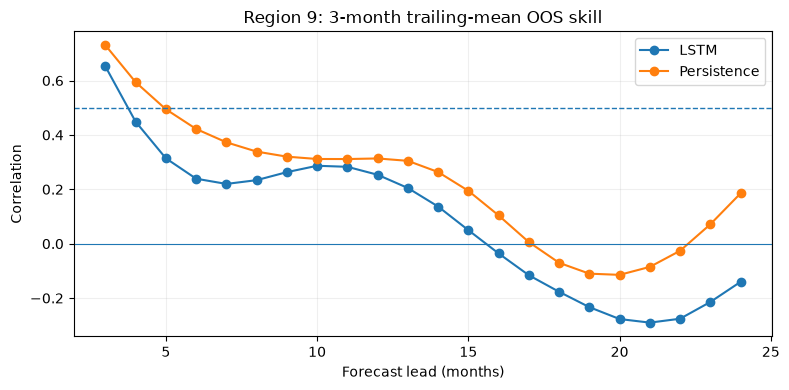

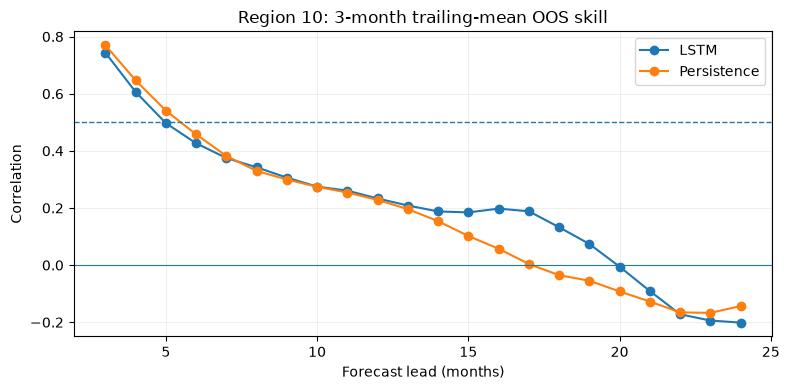

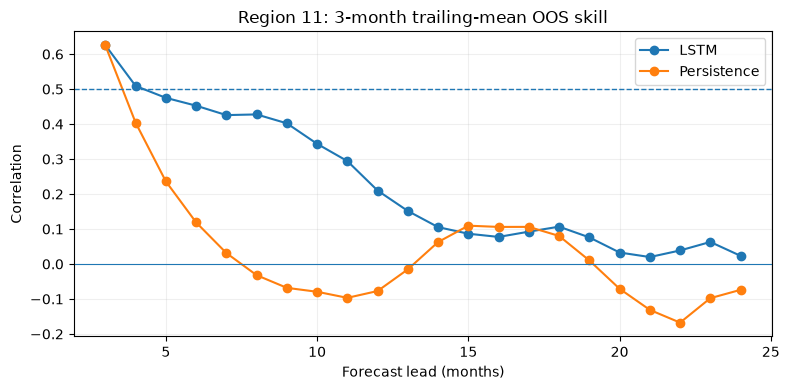

In [21]:
plot_skill_curves()

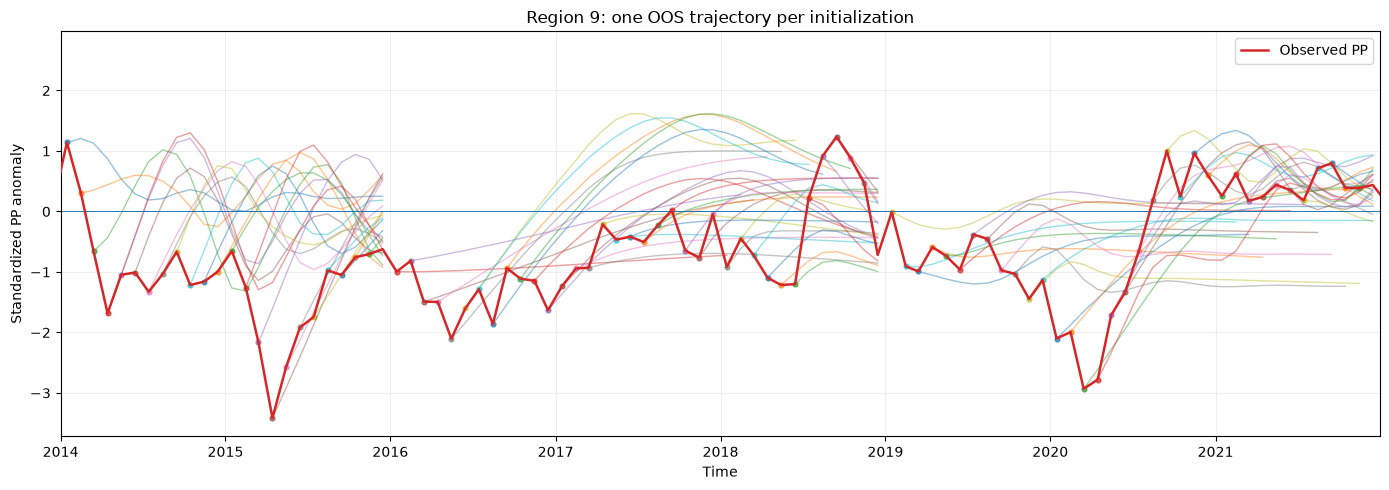

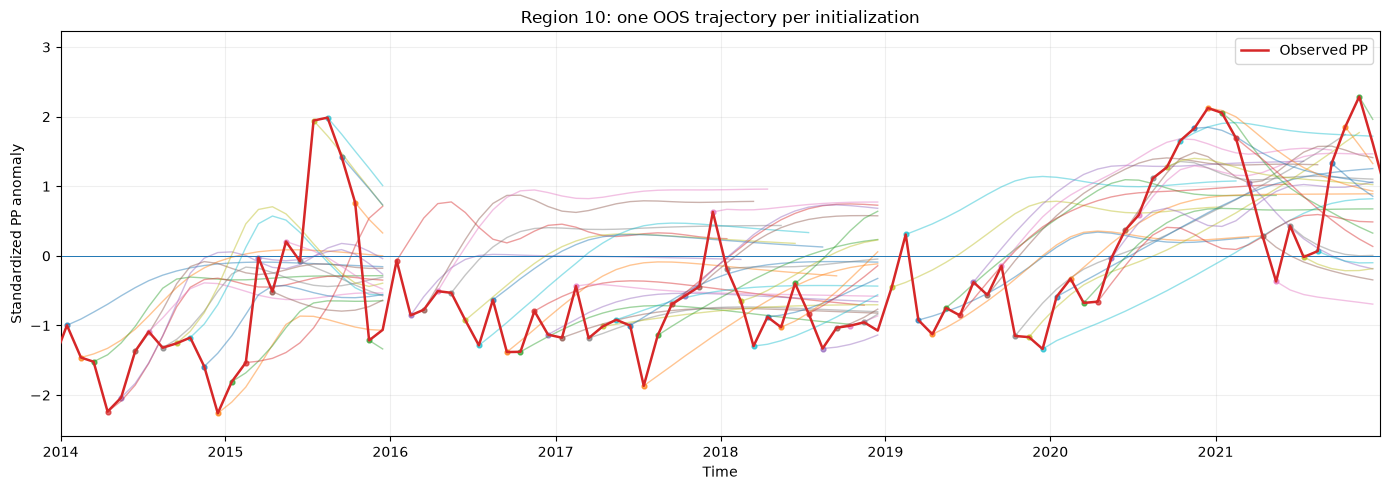

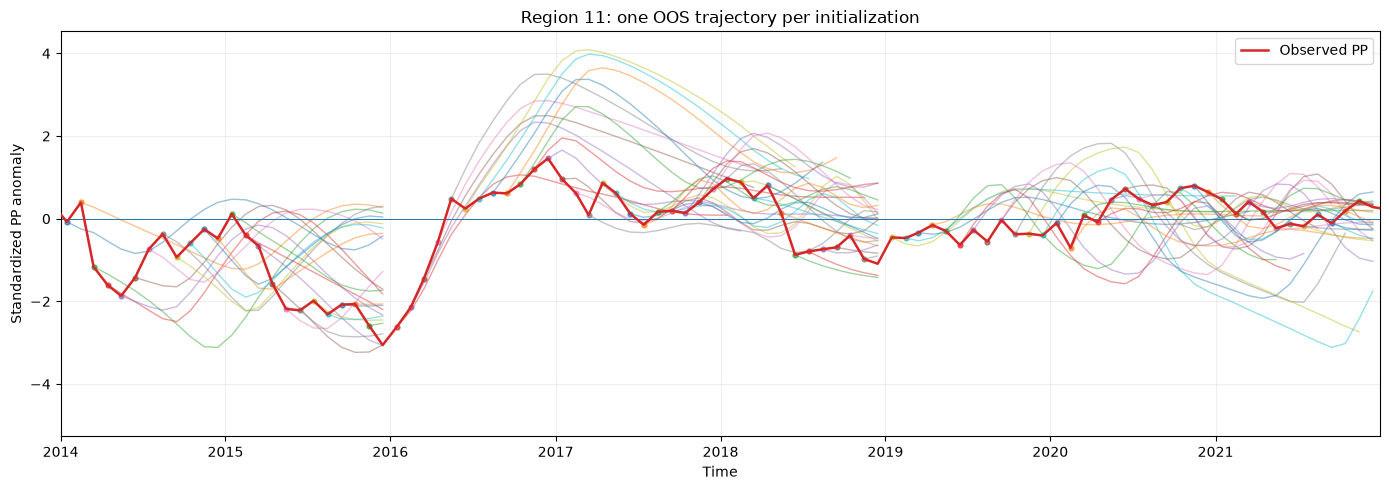

In [23]:
plot_spaghetti_region(9, every=1, start_date="2014-01-01", end_date="2021-12-31")
plot_spaghetti_region(10, every=1, start_date="2014-01-01", end_date="2021-12-31")
plot_spaghetti_region(11, every=1, start_date="2014-01-01", end_date="2021-12-31")